# Creation of the BGC climatology used for initialization and/or boundary conditions as well as restoring
- interpolates the GLODAPv2 data to the ocean physics input data
- Supported variables: nitrate, oxygen, DIC, and ALK.

In [10]:
import os
import xarray as xr

## Define your inputs

In [13]:
# Define the names of the reference experiment, file, and variable 
# used as the target grid for interpolation.
ref_exp = "jcope_nwpac025"
ref_file = "interp_T_01JAN1990.nc"
ref_var = "tm"
# Open the reference data array
ref_da = xr.open_dataset(f"../input/{ref_exp}/{ref_file}")[ref_var]

## You should not have to edit the rest

In [33]:
# Open the GLODAPv2 NO3 climatology
ds_climatology = xr.open_dataset("../climatology/GLODAPv2.2016b.MappedProduct/GLODAPv2.2016b.NO3.nc")
ds_climatology = ds_climatology.swap_dims({"depth_surface": "Depth"})
ds_climatology = ds_climatology.rename({"Depth": "depth"})
ds_climatology = ds_climatology["NO3"]
# Surprisingly, negative values exit in the original data, so set them to zeros
ds_climatology = ds_climatology.clip(min=0.0)
# Adjust Longitude to -180 to 180 convention
if ref_da["lon"].min() < 0:
    # This formula converts 0..360 (or 20..380) to -180..180
    ds_climatology.coords['lon'] = (ds_climatology.coords['lon'] + 180) % 360 - 180 
# Adjust Longitude to 0 to 360 convention
elif ref_da["lon"].max() > 180:
    ds_climatology.coords['lon'] = ds_climatology.coords['lon'] % 360
# If neither the above two cases, it means lon ranges 0-180 so either is fine
else:
    ds_climatology.coords['lon'] = ds_climatology.coords['lon'] % 360        
ds_climatology = ds_climatology.sortby("lon")

# 1. FLOOD the Source (Climatology)
# We fill NaNs horizontally using 'nearest' neighbor. 
# This extends the coastal values into the land, closing the gaps.
# Fill Longitude gaps first, then Latitude gaps
ds_filled = ds_climatology.interpolate_na(dim='lon', method='nearest', fill_value="extrapolate")
ds_filled = ds_filled.interpolate_na(dim='lat', method='nearest', fill_value="extrapolate")

# 2. INTERPOLATE to Target Grid (Model)
# Now source has no holes, so interp_like will always return data.
ds_regridded = ds_filled.interp_like(ref_da.isel(time=0))

# 3. FILL VERTICAL GAPS (only relevant if the target depth is beyond the input range)
ds_regridded = ds_regridded.ffill(dim='depth')

# Set negatives to zeros (interpolation can still produce tiny negatives)
ds_regridded = ds_regridded.clip(min=0)

# 4. MASK using Target Land Mask
# Finally, cut out the land according to YOUR model's definition.
# We use the water_mask we created earlier (~np.isnan(temp_ref))
# (Make sure water_mask is an xarray DataArray for this to work cleanly, or just use .where)
ds_final = ds_regridded.where(ref_da.isel(time=0).notnull())

# create directory if it does not exist
os.makedirs(f"../climatology/{ref_exp}", exist_ok=True)
ds_final.to_netcdf(f"../climatology/{ref_exp}/GLODAPv2.2016b.NO3_{ref_exp}.nc")

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = 'http://www.jamstec.go.jp/jcope/distributions/hakaseh/py-off-bgc-data/GLODAPv2.2016b.MappedProduct/GLODAPv2.2016b.NO3.nc', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

## Simple visualization to check if the output looks reasonable

In [24]:
# Check the min and max values
ds_final.min().values,ds_final.max().values

(array(0.), array(46.08309007))

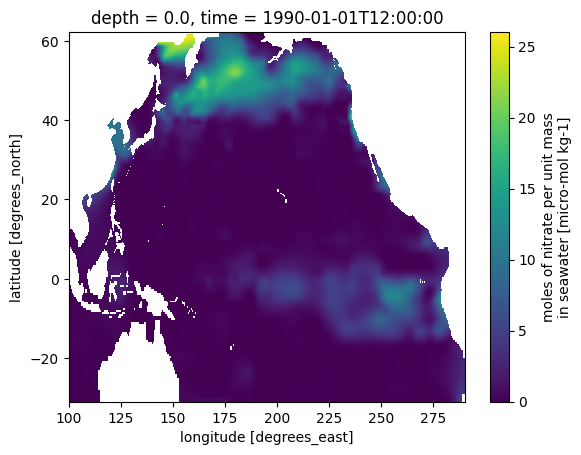

In [25]:
# in the uppermost layer
ds_final.isel(depth=0).plot()

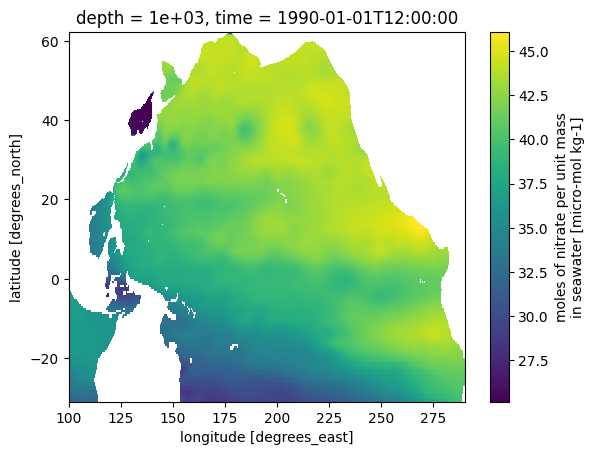

In [26]:
# in the deepest layer
ds_final.isel(depth=-1).plot()